# Emerging Technologies
**Name**: Macdarach Carty Joyce <br>
**ID**: G00394925

## Introduction


### Setup & Imports

In [1]:
import numpy as np
import random
import itertools
import qiskit
import qiskit_aer as aer
import matplotlib.pyplot as plt
import pylatexenc

## Problem 1: Generating Random Boolean Functions
<hr>
<br>
This problem relates to the implementation of a function that returns a boolean output based on a fixed number of boolean inputs. The function may either be <b>constant</b> (always return <code>True</code> or <code>False</code>) or <b>balanced</b> (half of possible combinations return <code>True</code>). This is achieved by generating and returning a function from <i>within</i> another function, the former of which then outputs a boolean output. The goal is to implement this so that the nature of the function (be it constant or balanced) remains unknown to the observer.  

In this case, for $x=\{0,1\}$, a randomly chosen function will either be: 
- **Constant**: Always return 0 ($f_0$) or always return 1 ($f_3$) regardless of input combination.
- **Balanced**: Return 0 for half of the input combinations and 1 for the other half ($f_1, f_2$).   

| $x$ | $f_0(x)$ | $f_1(x)$ | $f_2(x)$ | $f_3(x)$ |
|-----|---------|---------|---------|---------|
|  0  |    0    |    0    |    1    |    1    |
|  1  |    0    |    1    |    0    |    1    |

The approach used here begins with the generation of all possible binary strings of length $n$. If $n = 4$, this would mean generating $2^4$ possible combinations of binary strings: $[0, 0, 0, 0], [0, 0, 0, 1], [0, 0, 1, 0], [0, 0, 1, 1],...[1, 1, 1, 1]$. Once all possible combinations are acquired, only the constant (all 0's or 1's) or balanced (exactly half 1's) strings are returned.

### Defining the function to acquire all possible binary strings

In [2]:
def constant_and_balanced_strings(n):
    """
    Generates all constant and balanced binary strings of length n.
    
    Parameters:
        n (int): Length of the binary strings.
    Returns:
        np.ndarray: Array of constant and balanced binary strings.
    """
    # Generate all possible binary strings of length n
    all_binary_strings = ((np.arange(2**n)[:, None] & (1 << np.arange(n-1, -1, -1))) > 0).astype(int)

    # Acquire the sum of ones in each binary string
    ones = all_binary_strings.sum(axis=1)

    # Length of a binary string
    str_len = all_binary_strings.shape[1]

    # Return only the constant (all 0s or all 1s) or balanced (equal number of 0s and 1s) strings
    return all_binary_strings[(ones == 0) | (ones == str_len) | (ones == str_len // 2)]

Once the relevant strings have been returned, a random choice is made to either use a constant or balanced string before proceeding to choose a random string of either category. An inner variadic function is generated which maps the boolean inputs to the randomly selected string using standard binary-to-decimal conversion to calculate the index.  

Given $n$ binary inputs, the binary-to-decimal conversion formula would be as follows: <br>
<br>
$b_0 \times 2^0 + b_1 \times 2^1 ... + b_{n-1} \times 2^{n-1}$

So, given a balanced truth table of $[1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0]$, and the boolean inputs $(0, 1, 0, 1)$, by reversing the bit order to start with the least significant bit, we calculate the index as: <br>
<br>
$1 \times 2^0 + 0 \times 2^1 + 1 \times 2^2 + 0 \times 2^3 = 1 + 0 + 4 + 0 = 5$. 

Element $[5]$ is then acquired from the above truth table, which is $0$. Therefore, the specific input combination of $(0, 1, 0, 1)$ returns an output of 0.

### Generate and return the function 

In [3]:
def random_constant_balanced(n):
    """
    Creates and returns a function that randomly selects a binary string.

    Parameters:
        n (int): Number of input bits for the function.
    Returns:
        function: A function that maps n inputs to a randomly selected constant or balanced binary string.
    """
    
    # Acquire all constant and balanced strings of length 2^n
    strings = constant_and_balanced_strings(2 ** n)

    constant_strings = [s for s in strings if s.sum() == 0 or s.sum() == len(s)]
    balanced_strings = [s for s in strings if s.sum() == len(s) // 2]

    # Decide whether to select a constant or balanced string.
    string_type = random.choice(['constant', 'balanced'])

    # Randomly select one of these strings
    if string_type == 'constant':
        random_string = random.choice(constant_strings)
    else:
        random_string = random.choice(balanced_strings)

    
    def f(*args):
        """
        Maps n inputs to the corresponding bit in the randomly selected binary string.

        Parameters:
            *args: n binary inputs (0 or 1).
        Returns:
            int: The bit in the random string corresponding to the binary index formed by the inputs.
        """

        index = 0

        # Get index from binary inputs
        for i, bit in enumerate(reversed(args)):
            # Calculate the index in decimal (bit*2^0 + bit*2^1 + ... + bit*2^(n-1))
            index += (bit * (2 ** i))
            
        return int(random_string[index])
    
    # Store n as an attribute for later use
    f.n = n
    
    return f

### Test the function

In [4]:
# Acquire the function 
f = random_constant_balanced(4)

In [5]:
# Test the function with binary inputs
print(f(1, 1, 1, 1))

0


## Problem 2: Classical Testing for Function Type
<hr>

This section involves determining whether the function previously generated in [Problem 1](#problem-1-generating-random-boolean-functions) is constant or balanced. This is a [Classical](https://quantum.cloud.ibm.com/learning/en/courses/basics-of-quantum-information/single-systems/classical-information) approach; that is, the state of the function is clearly observed and known with certainty. If this determination were to be labelled as X, and there is a 50% chance of the function being either constant or balanced, we can represent the probabilities of such as:

$$Pr(X = constant) = \frac{1}{2} \quad \text{and} \quad Pr(X = balanced) = \frac{1}{2}$$

which can also be represented as a **column vector**: 

$$\begin{pmatrix} \frac{1}{2} \\ \\ \frac{1}{2} \end{pmatrix}$$

where the probability of the function being *constant* is placed at the top position, and the probability of the function being *balanced* is placed at the bottom, as well as the sum of these entries being always equal to 1.

The functions of [Deutsch's algorithm](https://quantum.cloud.ibm.com/learning/en/courses/fundamentals-of-quantum-algorithms/quantum-query-algorithms/deutsch-algorithm) can be represented as a 2x2 matrix, showing the output for each input:

$$
f_0(x) = \begin{pmatrix} 1 \quad 1 \\ 0 \quad 0 \end{pmatrix} \quad
f_1(x) = \begin{pmatrix} 1 \quad 0 \\ 0 \quad 1 \end{pmatrix} \quad
f_2(x) = \begin{pmatrix} 0 \quad 1 \\ 1 \quad 0 \end{pmatrix} \quad
f_3(x) = \begin{pmatrix} 0 \quad 0 \\ 1 \quad 1 \end{pmatrix} \quad
$$

When the the outcome of *determine_constant_balanced(f)* is observed, the classical state of the given function is known with certainty. This can be represented as a standard basis vector using the **dirac** notation, and is represented as:

$$
|constant\rangle = \begin{pmatrix} 
    1 \\ 0 
\end{pmatrix}

\quad \text{and} \quad

|balanced\rangle = \begin{pmatrix}
    0 \\ 1
\end{pmatrix}
$$
 In this approach, the output is determined by iterating through all possible input combinations against the truth table and analysing the result of <code>f</code>. The logic is as follows:

1. Get the output for the first input combination.
2. Iterate through the remaining operations.
3. If any output differs from the previous output, the function must be **balanced**.
4. If all outputs are the same and the loop completes, the function must be **constant**.

This can be determined after a minimum of 2 iterations (where the function is balanced), or after a maximum of $n$ iterations, where $n$ is equivalent to the number of input bits. 

In [6]:
def determine_constant_balanced(f):
    """
    Determines whether the given function is constant (returns 0 or 1 for all inputs) or 
    balanced (returns 0 for half of the inputs, 1 for the other half).

    Parameters: 
        f (function): The generated function being tested.

    Returns:
        A string saying whether the function is constant or balanced.
    """
    
    n = f.n  # Get number of inputs from the function attribute
    previous_output = None

    # Generate all possible input combinations dynamically
    all_inputs = itertools.product([0, 1], repeat=n)
    
    # Run f for all possible input combinations
    for i, inputs in enumerate(all_inputs):        
        out = f(*inputs)
        
        if previous_output is not None:
            # Output is different across different input combinations -- must be balanced.
            if out != previous_output:
                return "Balanced"
        
        # Store current output to compare with in next iteration.
        previous_output = out
    
    return "Constant"  # If all outputs are the same

### Execute the function

In [7]:
determine_constant_balanced(f)

'Constant'

## Problem 3: Quantum Oracles
<hr>


In [Quantum Information](https://quantum.cloud.ibm.com/learning/en/courses/basics-of-quantum-information/single-systems/quantum-information), the state of a given input is measured more arbitrarily than that of classical states. A quantum state differs to a classical probabilisitic state, where entries of a quantum state vector are *complex numbers*, and that the sum of the *absolute values squared* of the entries is equal to $1$. In a classical state set of $\{0, 1\}$, the term *qubit* is used to refer to a unit of quantum information. 

The processing of quantum information differs to classical information; a process that evaluates a function $f$ using an input of 0 or 1 to determine whether it is **constant** or **balanced** would have to be run at least twice under classical methods (as demonstrated in [Problem 2](#problem-2-classical-testing-for-function-type)), whereas the use of quantum information and operations allows for the determination of $f$ in one evaluation.

With the operation being unknown to the observer, the only properties that are known are the inputs supplied and the given outputs. With regards to the previous problems; in the case of a single input, there are four possible Boolean functions. This section sees the creation of a quantum oracle using *Qiskit* for each of the possible single-Boolean-input functions.

[Quantum Oracles](https://quantumcomputing.stackexchange.com/questions/4625/what-exactly-is-an-oracle/4626#4626) act as the 'black-box' operations that evaluate $f$. In order to do this, it must be ensured that $f$ is invertible, as the input would not be known for all functions (constant 0 always produces an output of 0, but it would not be known whether the input was 0 or 1). To guarantee invertibility, two input qubits ($x, y$) are used, and return two output qubits ($x, y \oplus f(x)$), where $\oplus$ is the XOR value. So, the transformation is implemented as: 

$\ket{x}\ket{y} \rightarrow \ket{x} \ket{y} \oplus \ket{f(x)}$ 

and $f$ could be one of the four functions in Deutsch's Algorithm: 


| $x$ | $f_0(x)$ | $f_1(x)$ | $f_2(x)$ | $f_3(x)$ |
|:---:|:-------:|:-------:|:-------:|:-------:|
|  0  |    0    |    0    |    1    |    1    |
|  1  |    0    |    1    |    0    |    1    |


https://plato.stanford.edu/archives/fall2008/entries/qt-entangle/#5

### Creating the Quantum Oracles
State vectors can be used to map the outputs to a 4x4 unitary matrix which is then used as the oracle. The initial state vectors are acquired by calculating the tensor product of the column vectors of two inputs. For example, given the function being used is the *identity* function and the inputs $x, y$ were $(1, 0)$ = $\ket{10}$ respectively, then the output results $f_1(1) = 1$ and $y \oplus f(x) = 1$ can be represented as $\ket{11}$.

The output state vector that follows can be calculated as:

$$
\ket{11} = \begin{pmatrix} 0 \\ 1 \end{pmatrix} \otimes \begin{pmatrix} 0 \\ 1 \end{pmatrix} = 
\begin{pmatrix} 0 \\ 0 \\ 0 \\ 1 \end{pmatrix}
$$

The input state vector $\ket{10}$ can be mapped to the output state vector $\ket{11}$

$$\ket{10} = \begin{pmatrix} 0 \\ 0 \\ 1 \\ 0 \end{pmatrix} \rightarrow \ket{11} = \begin{pmatrix} 0 \\ 0 \\ 0 \\ 1 \end{pmatrix}$$


The state vectors follow the rule where the sum of all absolute values of the entries squared is equal to 1.

### Quantum Oracle for $f_0(x)$ - **Constant $0$**
Constant 0 function returns an output of 0 regardless of the input state:

$f(0) = 0 \quad f(1) = 0$

We also calculate $y \oplus f(x)$ to get the XOR of the two qubits and the output.

| $x$ | $y$ |  | $f(x)$ | $y \oplus f(x)$ |
|:---:|:---:|:---:|:---:|:---:|
|  0  |  0  |  $\rightarrow$ | 0 | 0 |
|  0  |  1  |  $\rightarrow$ | 0 | 1 |
|  1  |  0  |  $\rightarrow$ | 0 | 0 |
|  1  |  1  |  $\rightarrow$ | 0 | 1 |

Represented using the dirac notation: 

$\ket{00} \rightarrow \ket{00} \\$
$\ket{01} \rightarrow \ket{01} \\$
$\ket{10} \rightarrow \ket{10} \\$
$\ket{11} \rightarrow \ket{11} \\$

For this particular function, the output remains unchanged from the input. We can these results as column state vectors: 

$$U\begin{pmatrix} \ket{00} \\ \ket{01} \\ \ket{10} \\ \ket{11} \end{pmatrix} = \begin{pmatrix} \ket{00} \\ \ket{01} \\ \ket{10} \\ \ket{11} \end{pmatrix}$$

The row vector is acquired from each of these mappings so that 
$$r_0 \begin{pmatrix} \ket{00} \\ \ket{01} \\ \ket{10} \\ \ket{11} \end{pmatrix} = \ket{00} \rightarrow r_0 = (1 \quad 0 \quad 0 \quad 0) $$

This is repeated for the rest of the outputs, after which each row vector can be placed into a 4x4 unitary matrix.

$$
U_{f_0} = \begin{pmatrix}
1 & 0 & 0 & 0 \\
0 & 1 & 0 & 0 \\
0 & 0 & 1 & 0 \\
0 & 0 & 0 & 1
\end{pmatrix}
$$

Which is also the same as: 
$$
I \otimes I = 
\begin{pmatrix}
1 & 0 \\ 0 & 1
\end{pmatrix}
\otimes
\begin{pmatrix}
1 & 0 \\ 0 & 1
\end{pmatrix} = \begin{pmatrix}
1 & 0 & 0 & 0 \\
0 & 1 & 0 & 0 \\
0 & 0 & 1 & 0 \\
0 & 0 & 0 & 1
\end{pmatrix}
$$

Hence, the oracle for $f_0$ is created.

### Code Implementation

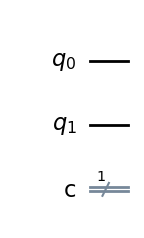

In [8]:
# Create oracle for constant 0 function
# Two qubits as inputs with one classical bit
oracle_0 = qiskit.QuantumCircuit(2, 1)

# Constant 0 function does not modify input qubits, so the oracle does not apply any gates in the circuit
# and leaves the qubits as they are.
oracle_0.draw('mpl')

### Quantum Oracle for $f_1(x)$ - **Identity Function**

The Identify function is one of the **balanced** functions, where it may return either 0 or 1. The Identity function returns whatever value the input was:

$f_1(0) = 0 \quad f_1(1) = 1$

| $x$ | $y$ |  | $f(x)$ | $y \oplus f(x)$ |
|:---:|:---:|:---:|:---:|:---:|
|  0  |  0  |  $\rightarrow$ | 0 | 0 |
|  0  |  1  |  $\rightarrow$ | 0 | 1 |
|  1  |  0  |  $\rightarrow$ | 1 | 1 |
|  1  |  1  |  $\rightarrow$ | 1 | 0 |

For the quantum circuit, since all qubits start at 0, the bit must be *flipped* if the input is 1, otherwise does nothing if the input is 0.

Once again, using the dirac notation to represent the inputs and outputs:

$\ket{00} \rightarrow \ket{00} \\$
$\ket{01} \rightarrow \ket{01} \\$
$\ket{10} \rightarrow \ket{11} \\$
$\ket{11} \rightarrow \ket{10} \\$

and mapping to their state row vectors: 

$$U\begin{pmatrix} \ket{00} \\ \ket{01} \\ \ket{10} \\ \ket{11} \end{pmatrix} = \begin{pmatrix} \ket{00} \\ \ket{01} \\ \ket{11} \\ \ket{10} \end{pmatrix}$$

$$r_0 = \ket{00} \rightarrow r_0 = (1 \quad 0 \quad 0 \quad 0) $$
$$r_1 = \ket{01} \rightarrow r_1 = (0 \quad 1 \quad 0 \quad 0) $$
$$r_2 = \ket{11} \rightarrow r_2 = (0 \quad 0 \quad 0 \quad 1) $$
$$r_3 = \ket{10} \rightarrow r_3 = (0 \quad 0 \quad 1 \quad 0) $$

The result being the **Controlled-Not** gate:

$$
U_{f_1} = \begin{pmatrix}
1 & 0 & 0 & 0 \\
0 & 1 & 0 & 0 \\
0 & 0 & 0 & 1 \\
0 & 0 & 1 & 0
\end{pmatrix} = CX
$$


### Code Implementation

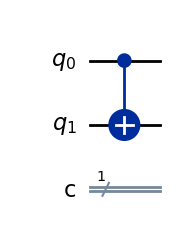

In [9]:
oracle_1 = qiskit.QuantumCircuit(2, 1)

# Apply the Controlled-NOT (CNOT) gate to flip the qubit if the input is 1.
oracle_1.cx(0, 1)

oracle_1.draw('mpl')

### Quantum Oracle for $f_2(x)$ - **NOT function**
The NOT function is another balanced function, and returns the opposite value of the given input:

$f_2(0) = 1 \quad f_2(1) = 0$

| $x$ | $y$ |  | $f(x)$ | $y \oplus f(x)$ |
|:---:|:---:|:---:|:---:|:---:|
|  0  |  0  |  $\rightarrow$ | 1 | 1 |
|  0  |  1  |  $\rightarrow$ | 1 | 0 |
|  1  |  0  |  $\rightarrow$ | 0 | 0 |
|  1  |  1  |  $\rightarrow$ | 0 | 1 |

$\ket{00} \rightarrow \ket{01} \\$
$\ket{01} \rightarrow \ket{00} \\$
$\ket{10} \rightarrow \ket{10} \\$
$\ket{11} \rightarrow \ket{11} \\$

When mapped:

$$U\begin{pmatrix} \ket{00} \\ \ket{01} \\ \ket{10} \\ \ket{11} \end{pmatrix} = \begin{pmatrix} \ket{01} \\ \ket{00} \\ \ket{10} \\ \ket{11} \end{pmatrix}$$

$$r_0 = \ket{01} \rightarrow r_0 = (0 \quad 1 \quad 0 \quad 0) $$
$$r_1 = \ket{00} \rightarrow r_1 = (1 \quad 0 \quad 0 \quad 0) $$
$$r_2 = \ket{10} \rightarrow r_2 = (0 \quad 0 \quad 1 \quad 0) $$
$$r_3 = \ket{11} \rightarrow r_3 = (0 \quad 0 \quad 0 \quad 1) $$

$$
U_{f_2} = \begin{pmatrix}
0 & 1 & 0 & 0 \\
1 & 0 & 0 & 0 \\
0 & 0 & 1 & 0 \\
0 & 0 & 0 & 1
\end{pmatrix} = I \otimes X(CX)
$$

### Code Implementation

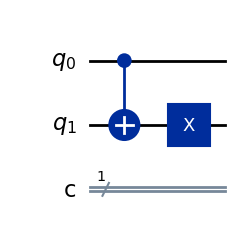

In [10]:
oracle_2 = qiskit.QuantumCircuit(2, 1)

# Apply the CNOT gate to flip the second qubit if and ONLY if input is |1>.
oracle_2.cx(0, 1)

# Apply the X gate to flip the target qubit.
oracle_2.x(1)

oracle_2.draw('mpl')

### Quantum Oracle for $f_3(x)$ - **Constant $1$**

The constant 1 function returns an output of 1 regardless of the state the input is in:

$f_3(0) = 1 \quad f_3(1) = 1$

| $x$ | $y$ |  | $f(x)$ | $y \oplus f(x)$ |
|:---:|:---:|:---:|:---:|:---:|
|  0  |  0  |  $\rightarrow$ | 1 | 1 |
|  0  |  1  |  $\rightarrow$ | 1 | 0 |
|  1  |  0  |  $\rightarrow$ | 1 | 1 |
|  1  |  1  |  $\rightarrow$ | 1 | 0 |

$\ket{00} \rightarrow \ket{01} \\$
$\ket{01} \rightarrow \ket{00} \\$
$\ket{10} \rightarrow \ket{11} \\$
$\ket{11} \rightarrow \ket{10} \\$

When mapped:

$$U\begin{pmatrix} \ket{00} \\ \ket{01} \\ \ket{10} \\ \ket{11} \end{pmatrix} = \begin{pmatrix} \ket{01} \\ \ket{00} \\ \ket{11} \\ \ket{10} \end{pmatrix}$$

$$r_0 = \ket{01} \rightarrow r_0 = (0 \quad 1 \quad 0 \quad 0) $$
$$r_1 = \ket{00} \rightarrow r_1 = (1 \quad 0 \quad 0 \quad 0) $$
$$r_2 = \ket{11} \rightarrow r_2 = (0 \quad 0 \quad 0 \quad 1) $$
$$r_3 = \ket{10} \rightarrow r_3 = (0 \quad 0 \quad 1 \quad 0) $$

$$
U_{f_3} = \begin{pmatrix}
0 & 1 & 0 & 0 \\
1 & 0 & 0 & 0 \\
0 & 0 & 0 & 1 \\
0 & 0 & 1 & 0
\end{pmatrix} = I \otimes X
$$

### Code Implementation

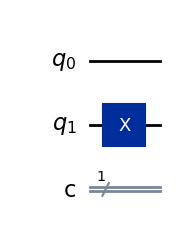

In [11]:
oracle_3 = qiskit.QuantumCircuit(2, 1)

# Since output would always be 1, apply the X gate to flip the qubit.
oracle_3.x(1)
oracle_3.draw('mpl')

## Problem 4: Deutsch's Algorithm with Qiskit
<hr>

This section sees the creation of a *quantum circuit* using each of the oracles created in [Problem 3](#problem-3-quantum-oracles) to solve Deutsch's problem. The circuit would allow the observer to determine whether the function being tested is constant or balanced after one query. 

In a typical quantum circuit, all qubits are intially set to the state $\ket{0}$, which can then be transformed by a series of gates/operations to produce an output of either $\ket{0}$ if the function is constant, or $\ket{1}$ if the function is balanced. One of these being the [Hadamard operation](https://pennylane.ai/qml/glossary/what-is-a-hadamard-gate), which transforms the state of a qubit into a state of a superposition between $\ket{0}$ and $\ket{1}$. Applying the Hadamard operation again to the same qubit reverses the transformation, collapsing the state of superposition.

$$
H = \frac{1}{\sqrt{2}}\begin{pmatrix}1 & 1 \\ 1 & -1\end{pmatrix}
$$

This gate is applied to both qubits at the start of the circuit, before then being transformed by the oracle for the respective function. This is always the first step of the quantum circuit regardless of the function being used.

https://pennylane.ai/qml/glossary/what-is-a-hadamard-gate - a simple and brief overview on the Hadamard operation.
https://quantum.cloud.ibm.com/learning/en/courses/fundamentals-of-quantum-algorithms/quantum-query-algorithms/deutsch-algorithm - an introduction to Deutsch's algorithm and the quantum circuit that computes the algorithm.


### Initial state vectors

The circuit can be computed and *verified* through a series of matrix multiplications starting with the **intital state vectors** of each possible input. The intial state vectors can be computed by acquiring the tensor product of the column vectors of a multi-qubit state. 

$$ 
\ket{00} = \begin{pmatrix} 1 \\ 0 \end{pmatrix} \otimes \begin{pmatrix} 1 \\ 0 \end{pmatrix} 
= \begin{pmatrix} 1 \\ 0 \\ 0 \\ 0 \end{pmatrix} \quad

\ket{01} = \begin{pmatrix} 1 \\ 0 \end{pmatrix} \otimes \begin{pmatrix} 0 \\ 1 \end{pmatrix} 
= \begin{pmatrix} 0 \\ 1 \\ 0 \\ 0 \end{pmatrix} \quad
$$
$$
\ket{10} = \begin{pmatrix} 0 \\ 1 \end{pmatrix} \otimes \begin{pmatrix} 1 \\ 0 \end{pmatrix} 
= \begin{pmatrix} 0 \\ 0 \\ 1 \\ 0 \end{pmatrix} \quad

\ket{11} = \begin{pmatrix} 0 \\ 1 \end{pmatrix} \otimes \begin{pmatrix} 0 \\ 1 \end{pmatrix} 
= \begin{pmatrix} 0 \\ 0 \\ 0 \\ 1 \end{pmatrix} \quad
$$


### Beginning the circuit

At the start of the circuit, both qubits are initialised as $\ket{0}$. The second qubit can be flipped to $\ket{1}$ by applying the NOT gate ($X$) to it before applying any other operation.

$$X = \begin{pmatrix} 0 & 1 \\ 1 & 0 \end{pmatrix}$$

The first qubit is left alone, which is equivalent to applying the Identity gate ($I$).

$$I = \begin{pmatrix} 1 & 0 \\ 0 & 1 \end{pmatrix}$$

Hence, the first computational step of the quantum circuit is multiplying the initial state vector with the *tensor product of $I$ and $X$*. If the input were to be $\ket{00}$, the matrix multiplication steps thus far look like:

$$ I \otimes X = \begin{pmatrix} 1 & 0 \\ 0 & 1 \end{pmatrix} \otimes \begin{pmatrix} 0 & 1 \\ 1 & 0\end{pmatrix}
= \begin{pmatrix}
0 & 1 & 0 & 0 \\
1 & 0 & 0 & 0 \\
0 & 0 & 0 & 1 \\
0 & 0 & 1 & 0
\end{pmatrix}

\cdot \begin{pmatrix} 1 \\ 0 \\ 0 \\ 0 \end{pmatrix} = \begin{pmatrix} 0 \\ 1 \\ 0 \\ 0 \end{pmatrix}
$$

A Hadamard operation is then applied to both qubits so as to transform them into a state of superposition. Since there is a Hadamard operation for each qubit, the tensor product of two Hadamard gates is calculated. 

$$
H \otimes H = \frac{1}{\sqrt{2}}\begin{pmatrix}1 & 1 \\ 1 & -1\end{pmatrix} \otimes \frac{1}{\sqrt{2}}\begin{pmatrix}1 & 1 \\ 1 & -1\end{pmatrix} 
= \frac{1}{2} \begin{pmatrix}
1 & 1 & 1 & 1 \\
1 & -1 & 1 & -1 \\
1 & 1 & -1 & -1 \\
1 & -1 & -1 & 1
\end{pmatrix}

\cdot \begin{pmatrix} 0 \\ 1 \\ 0 \\ 0 \end{pmatrix} = \frac{1}{2}\begin{pmatrix}1 \\ -1 \\ 1 \\ -1 \end{pmatrix}
$$


### Code implementation - start

This code shows the quantum circuit that had been computed thus far. The two qubits are initialised to $\ket{0}$, hence the X gate flips $q_1$ to $\ket{1}$. There is no identity gate shown for $q_0$, as it does not need to be represented since it does not affect the state of the qubit. The transformation $I \otimes X$ is still performed regardless.

The two Hadamard gates are also shown, applied to both qubits.

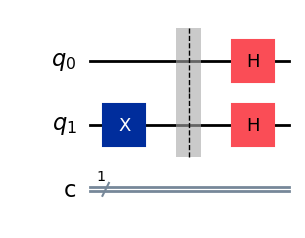

In [12]:
# The beginning portion of the overall circuit
deutsch_s = qiskit.QuantumCircuit(2, 1)

# Apply the NOT gate to q1 to flip state from |0> to |1>.
deutsch_s.x(1)

deutsch_s.barrier()

# Apply Hadamard gates to both qubits
deutsch_s.h((0, 1))

deutsch_s.draw(output='mpl')

### Applying the Quantum Oracle to the Circuit

The next verification step is applying one of the oracles generated in [Problem 3](#problem-3-quantum-oracles) to the circuit. The identity function will be used in this verification example, the oracle of which implementing the CNOT gate. 

$$
CX = \begin{pmatrix}
1 & 0 & 0 & 0 \\
0 & 1 & 0 & 0 \\
0 & 0 & 0 & 1 \\
0 & 0 & 1 & 0
\end{pmatrix}
$$

Then, performing matrix multiplication with the current state vector:
$$
\begin{pmatrix}
1 & 0 & 0 & 0 \\
0 & 1 & 0 & 0 \\
0 & 0 & 0 & 1 \\
0 & 0 & 1 & 0
\end{pmatrix}

\cdot \frac{1}{2} \begin{pmatrix} 1 \\ -1 \\ 1 \\ -1 \end{pmatrix} = \frac{1}{2} \begin{pmatrix} 1 \\ -1 \\ -1 \\ 1 \end{pmatrix}
$$

Of course, this varies depending on function used.

### Completing the Circuit

Upon completion of the oracle transformation, another Hadamard gate is applied to the top qubit, whereas the bottom qubit is left unchanged. This is equivalent to $H \otimes I$, and is calculated as follows:

$$
H \otimes I = \frac{1}{\sqrt{2}} \begin{pmatrix}1 & 1 \\ 1 & -1 \end{pmatrix} \otimes \begin{pmatrix}1 & 0 \\ 0 & 1 \end{pmatrix}
= \frac{1}{\sqrt{2}} \begin{pmatrix}
1 & 0 & 1 & 0 \\
0 & 1 & 0 & 1 \\
1 & 0 & -1 & 0 \\
0 & 1 & 0 & -1
\end{pmatrix}
$$

Hence the final transformation of the current state can be represented as follows:

$$
\frac{1}{\sqrt{2}} \begin{pmatrix}
1 & 0 & 1 & 0 \\
0 & 1 & 0 & 1 \\
1 & 0 & -1 & 0 \\
0 & 1 & 0 & -1
\end{pmatrix}

\cdot \frac{1}{2}\begin{pmatrix}1 \\ -1 \\ -1 \\ 1 \end{pmatrix} = \frac{1}{2\sqrt{2}} \begin{pmatrix} 0 \\ 0 \\ 2 \\ -2 \end{pmatrix} 
= \frac{1}{\sqrt{2}} \begin{pmatrix} 0 \\ 0 \\ 1 \\ -1 \end{pmatrix}
$$ 

The final state vector has a value greater than zero on the positions $\ket{10}$ and $\ket{11}$. 

### Code implementation - end

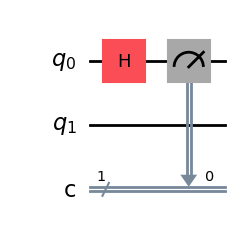

In [13]:
# Create end part of circuit
deutsch_e = qiskit.QuantumCircuit(2, 1)

# Apply final Hadamard gate to first qubit
deutsch_e.h(0)

deutsch_e.measure(0, 0)

deutsch_e.draw(output='mpl')

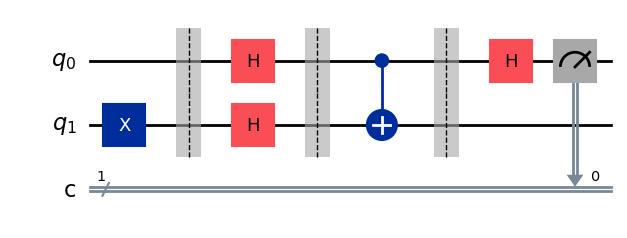

In [14]:
# Create a full circuit composed of start, end and oracle
full_circuit = qiskit.QuantumCircuit(2, 1)

# Add beginning of circuit
full_circuit.compose(deutsch_s, inplace=True)
full_circuit.barrier()

# Use identity oracle as example
full_circuit.compose(oracle_1, inplace=True)
full_circuit.barrier()

# Add end of circuit
full_circuit.compose(deutsch_e, inplace=True)

full_circuit.draw(output='mpl')

## Problem 5: Scaling to the Deutsch-Jozsa Algorithm